In [20]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


# Gráficos mais avançados

Uma biblioteca muito útil para a geração de gráficos com um visual mais agradável.

In [21]:

vg = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')
vgplat = vg.groupby(['Platform'])


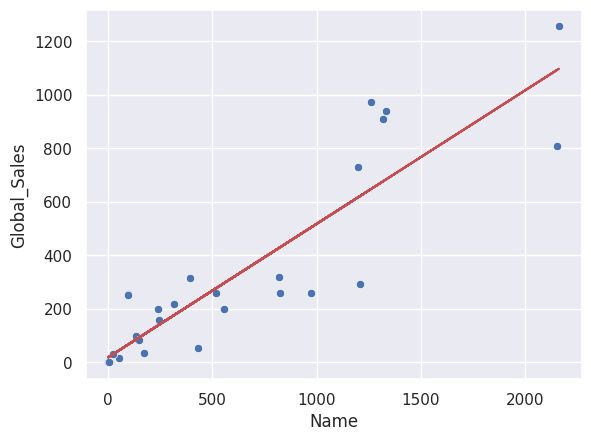

In [22]:
from sklearn import datasets, linear_model
x = vgplat.Name.count()
y = vgplat.Global_Sales.sum()
regr = linear_model.LinearRegression()
regr.fit(np.array(x).reshape(-1, 1), np.array(y).reshape(-1, 1))

sns.scatterplot(x=x,y=y)
plt.plot(x,regr.predict(np.array(x).reshape(-1, 1)),'r-')

<Axes: xlabel='Total de Jogos', ylabel='Vendas'>

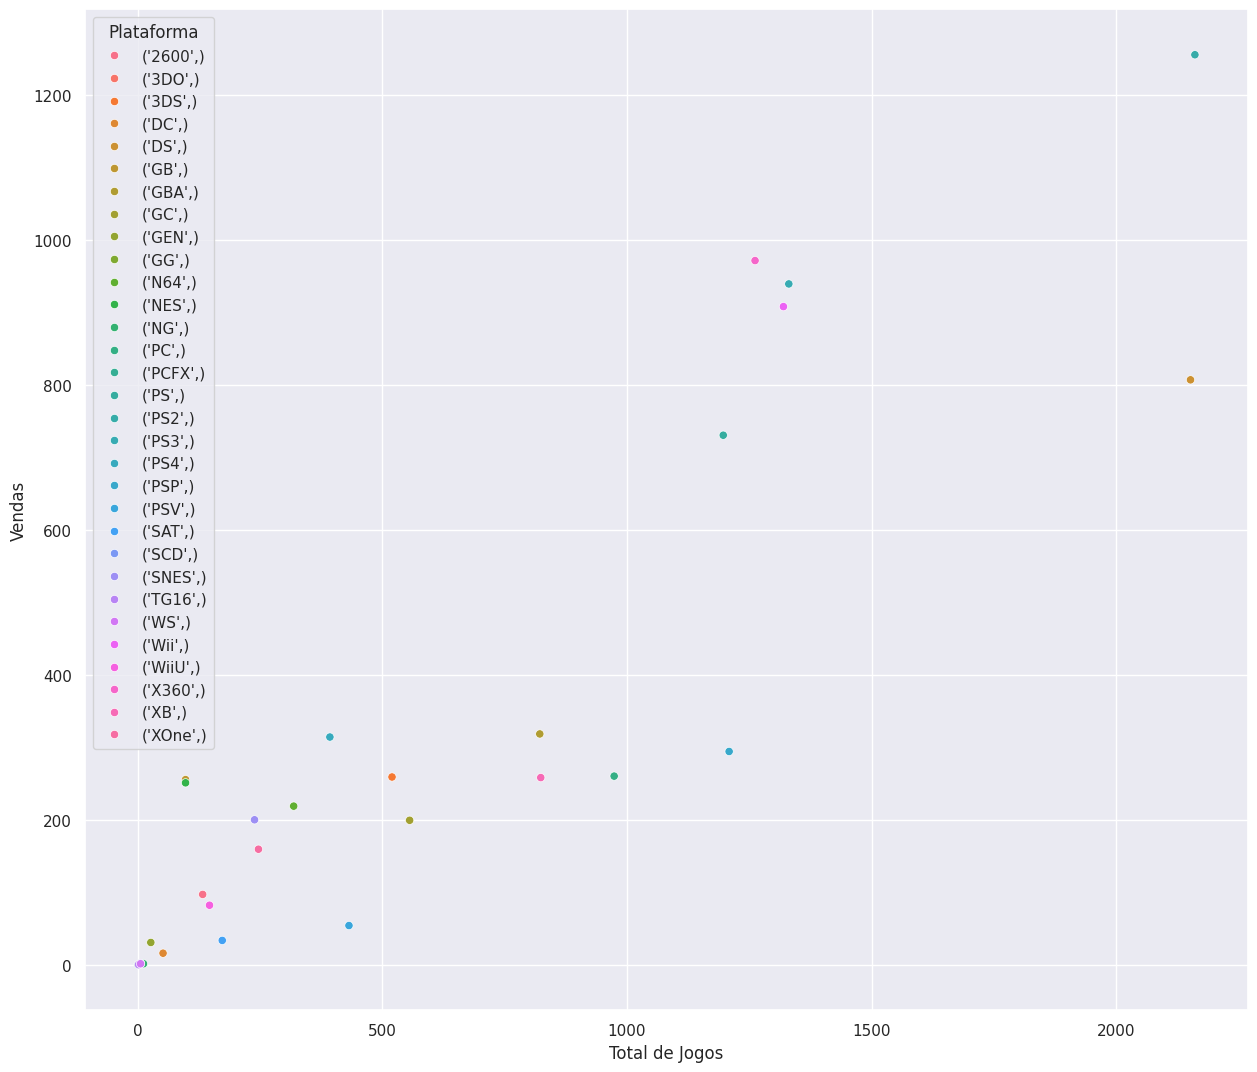

In [23]:
x = vgplat.Name.count()
y = vgplat.Global_Sales.sum()

scat = pd.DataFrame(list(zip(list(dict(list(vgplat)).keys()),x,y)),columns=['Plataforma','Total de Jogos','Vendas'])


plt.figure(figsize=(15,13))
sns.set(style="darkgrid")
sns.scatterplot(x='Total de Jogos',y='Vendas',hue='Plataforma',data=scat,)

<Axes: xlabel='Total de Jogos', ylabel='Vendas'>

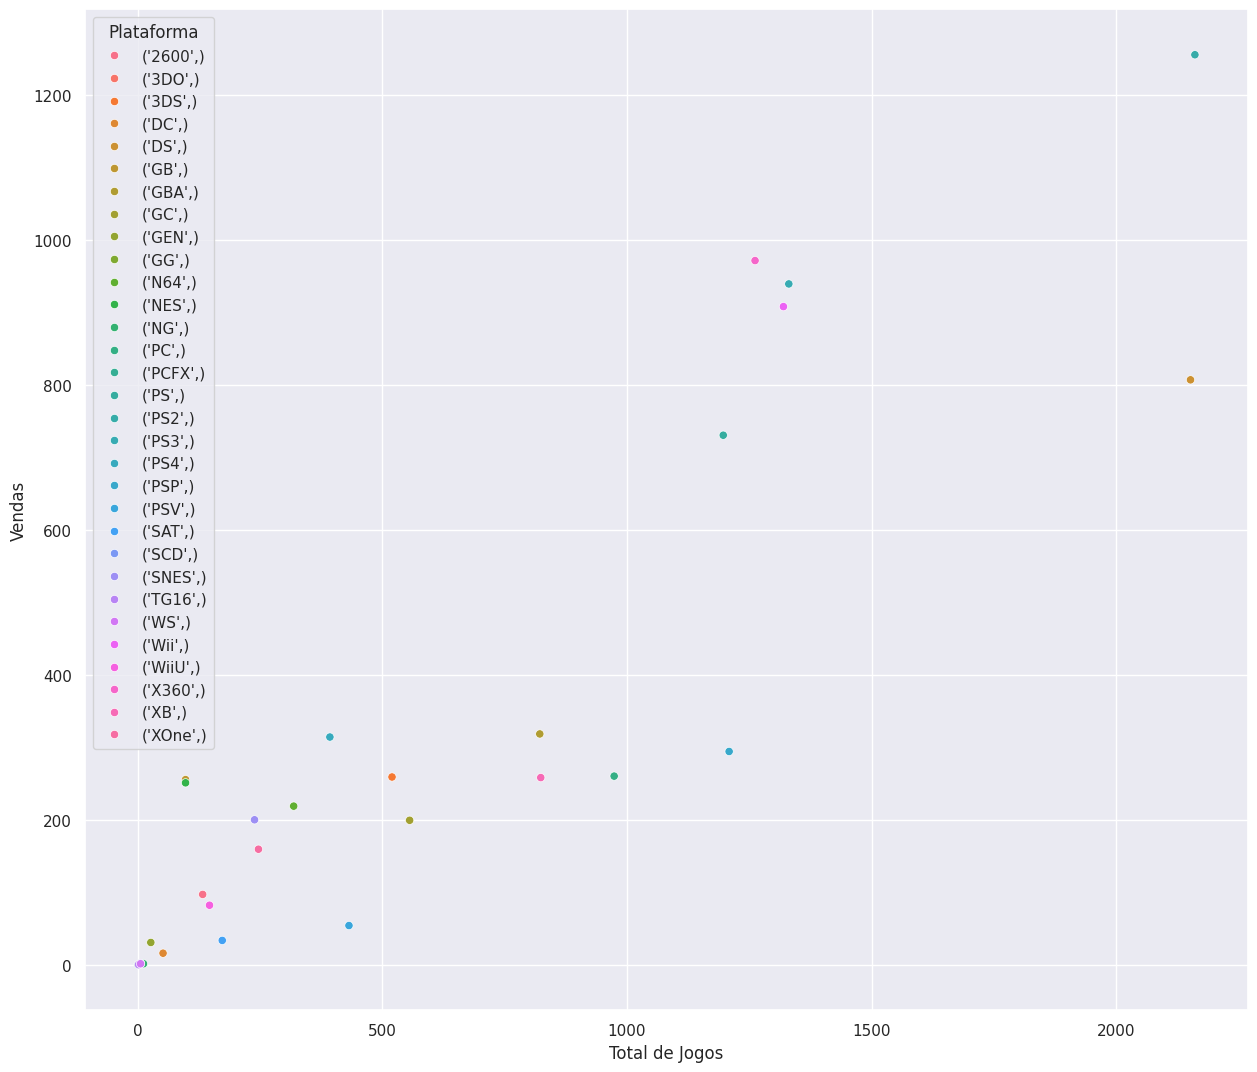

In [24]:
x = vgplat.Name.count()
y = vgplat.Global_Sales.sum()

scat = pd.DataFrame(list(zip(list(dict(list(vgplat)).keys()),x,y)),columns=['Plataforma','Total de Jogos','Vendas'])


plt.figure(figsize=(15,13))
sns.set(style="darkgrid")
sns.scatterplot(x='Total de Jogos',y='Vendas',hue='Plataforma',data=scat,)

# Explorando dados Binários e Categóricos

Uma forma simples de visualizar uma variável binária ou categórica com poucas categorias é simplesmente contar quantos elementos existem em cada categoria.

In [25]:
vg = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')


<Figure size 1500x1300 with 0 Axes>

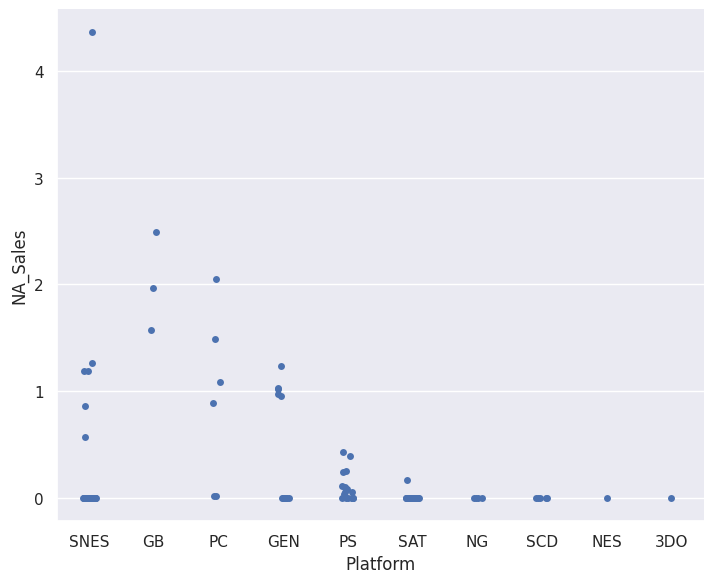

In [26]:
plt.figure(figsize=(15,13))
sns.set(style="darkgrid")
sns.catplot(x='Platform',y='NA_Sales',data=vg[vg.Year_of_Release==1994],height=6,aspect=1.2)

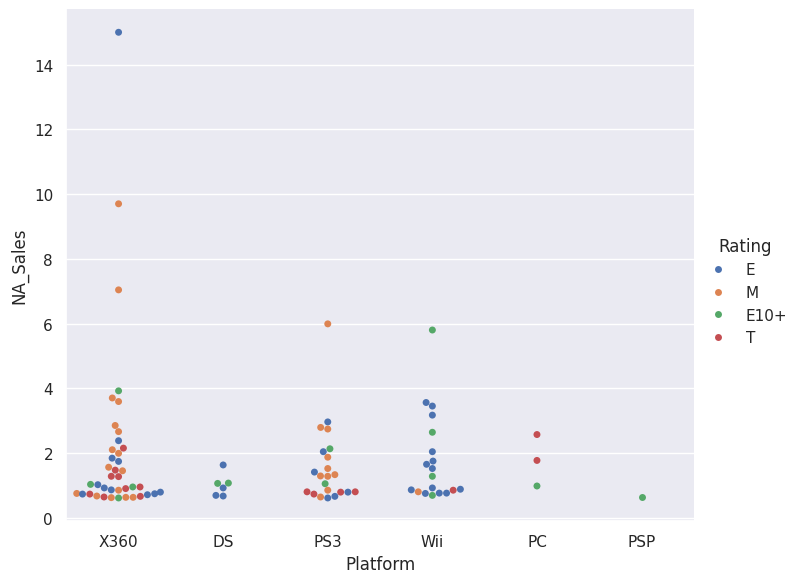

In [27]:
sns.catplot(x='Platform',y='NA_Sales',data=vg[(vg.Year_of_Release==2010)&(vg.NA_Sales>0.6)],hue='Rating',kind="swarm",height=6,aspect=1.2)

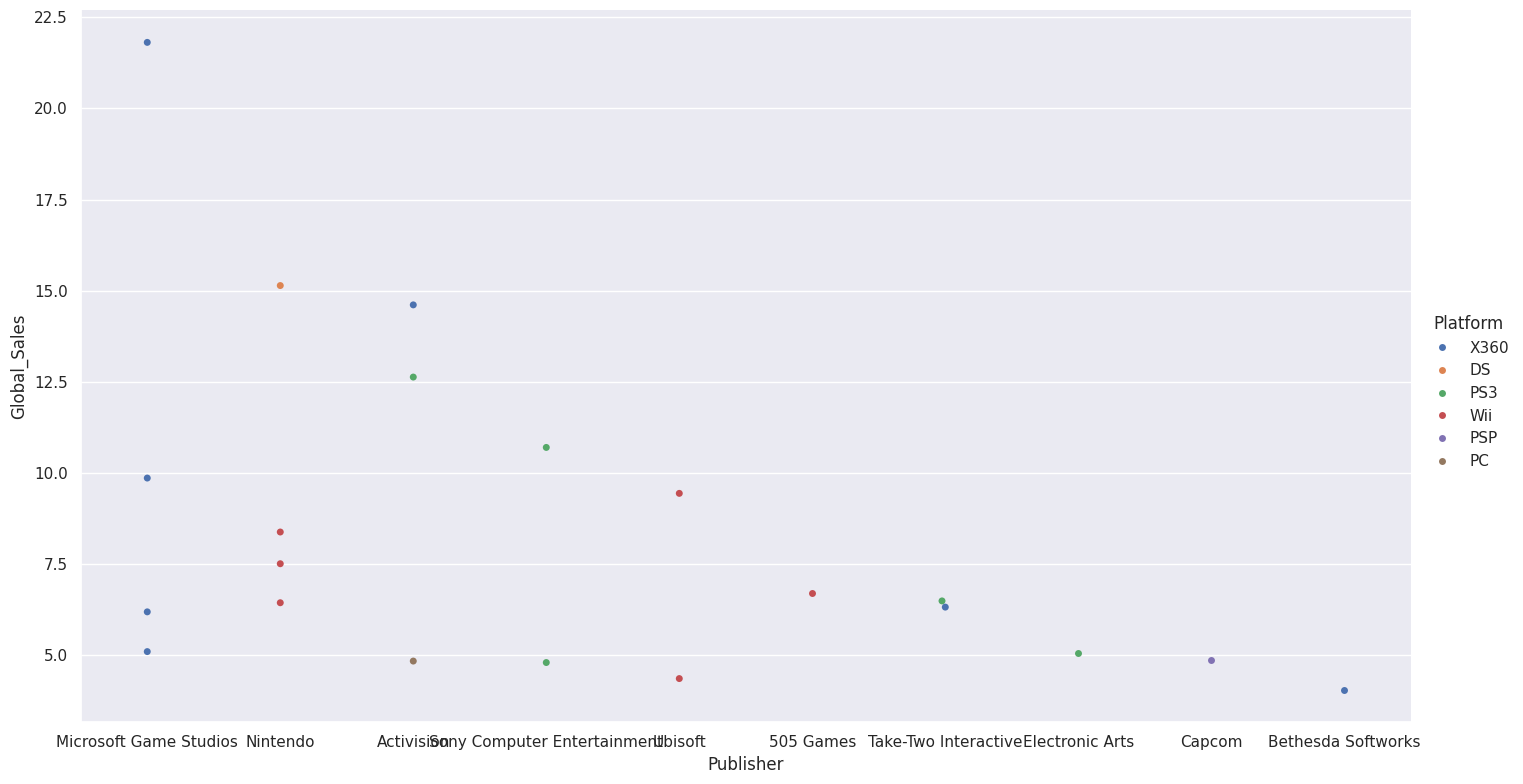

In [28]:
#Plotar Publisher X vendas globais >4, com as cores sendo a plataforma
sns.catplot(x='Publisher',y='Global_Sales',data=vg[(vg.Year_of_Release==2010)&(vg.Global_Sales>4)],hue='Platform',kind="swarm",height=8,aspect=1.8)

/tmp/ipython-input-52651241.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Rating',y = 'Total',data=plota,kind='bar',palette="muted")


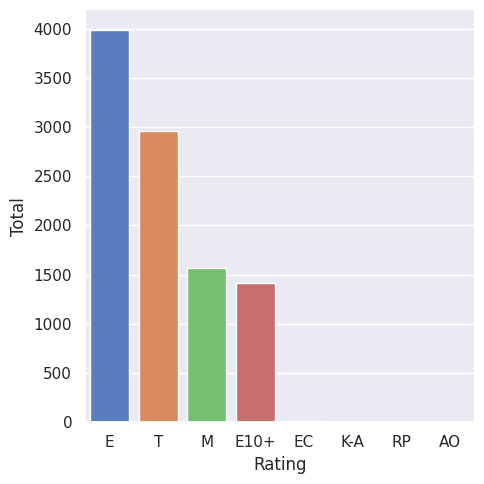

In [29]:
plota = pd.DataFrame(vg.Rating.value_counts()).reset_index()
plota.columns = ['Rating','Total']
sns.catplot(x='Rating',y = 'Total',data=plota,kind='bar',palette="muted")

Além de gráficos de barra, outra representação poular é o uso de gráficos de pizza, mas é um consenso entre estatísticos e cientistas de dados que eles são péssimos.

![Gráfico de Pizza](https://bernardmarr.com/img/piechartarticle-1.jpg)
![Gráfico de Pizza](https://bernardmarr.com/img/piechartarticle-2.jpg)

## Moda

A Moda é um valor (ou conjunto de valores em caso de empates) que mais aparecem nos dados (categóricos, normalmente).

In [30]:
vg[['Platform','Rating']].mode()

,Platform,Rating
0,PS2,E


# Correlações

Análise de dados exploratória muitas vezes usa a correlação entre variáveis para encontrar padrões interessantes.

Duas variáveis X e Y são __positivamente correlacionadas__ se um crescimento nos valores de X é acompanhado de um crescimento correspondente em X, e __negativamente correlacionadas__ se conforme X cresce Y diminui.

Considere estas duas variáveis, perfeitamente positivamente correlacionadas:

$$
v1: \{1,2,3\}\\
v2: \{4,5,6\}
$$

O soma do produto vetorial entre eles seria $4+10+18=32$. Não importa como você embaralhe os valores de v1 e v2, a soma do produto vetorial sempre será menor que 32.

Assim, esta comparação entre a soma dos vetores originais e diversas outras permutações pode ser usada como uma métrica de comparação (veremos mais a frente isto como teste de permutão).

Contudo, os valores produzidos por esta métrica não são grandes coisas.

Uma variação mais interessante é o coeficiente de correlação $r$, que estima a correlação entre duas variáveis e tem resultados sempre na mesma escala.

O coeficiente de _Pearson_ é calculado multiplicando os desvios da média da variável 1 pelos da variável 2 dividido pelo produto dos desvios padrões:

$$ r = \frac{\sum_{i=1}^{N}{(x_i-\overline{x})(y_i-\overline{y})}}{\sigma_x\sigma_y} $$

*tecnicamente é $s$ ao invés de $\sigma$ se for uma amostra.



In [31]:
pr = vg[(vg.Platform=='PS3')&vg.Critic_Score.notnull()]
stats.pearsonr(pr.NA_Sales,pr.Critic_Score)

PearsonRResult(statistic=np.float64(0.45451206312848413), pvalue=np.float64(4.812691004171893e-43))

Variáveis podem ter relações não-lineares, e neste caso o valor de correlação _linear_ vai ser pouco útil.

Mas e quando eu tenho muitas variáveis, eu vou ter que rodar pearson 2 a 2 para buscar correlações? Sim, mas temos uma forma mais simples, usando matrizes de correlação:

<Axes: >

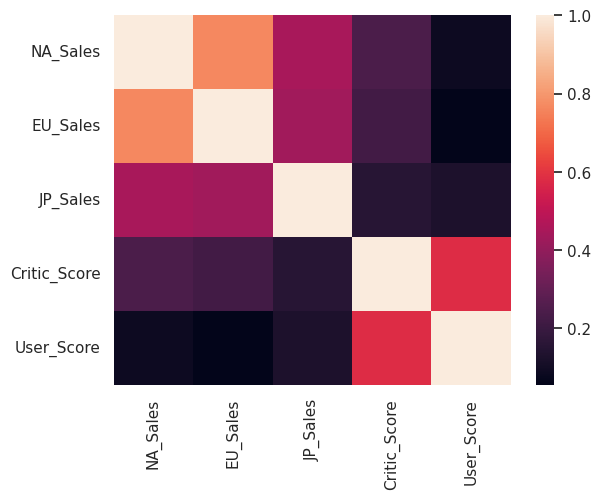

In [32]:
sns.heatmap(vg[['NA_Sales','EU_Sales','JP_Sales','Critic_Score','User_Score']].corr())

## Explorando duas ou mais variáveis

Estimadores que vimos até agora em sua maioria tratam de uma só variável (análise univariada). As correlações são análises bivariadas. Agora vamos ver alguns métodos de análise multivariada.

Scatterplots e afins são úteis para poucos valores, como pudemos ver acima. Para conjuntos com milhares ou milhões de registros, ele vai ficar muito denso.

Uma forma legal de visualizar dados muito densos são os _hex binning plots_.


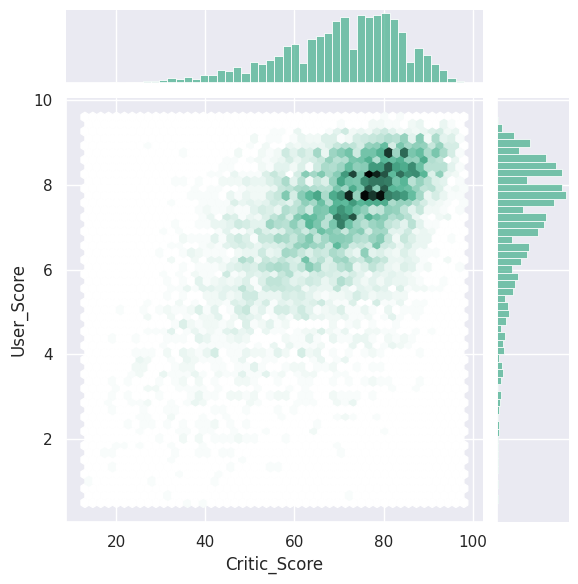

In [33]:
sns.jointplot(x=vg.Critic_Score, y=vg.User_Score, kind="hex", color="#4CB391")

/tmp/ipython-input-1685803717.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=pl.User_Score, y=pl.Critic_Score, cmap="Reds", shade=True, bw_adjust=.5)


<Axes: xlabel='User_Score', ylabel='Critic_Score'>

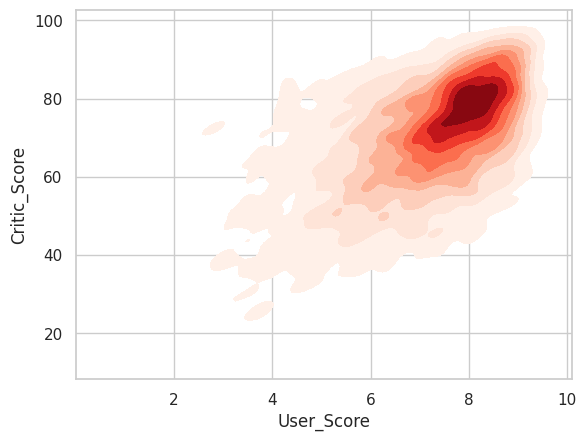

In [34]:
pl = vg
sns.set(style="whitegrid")
sns.kdeplot(x=pl.User_Score, y=pl.Critic_Score, cmap="Reds", shade=True, bw_adjust=.5)

### Dados categóricos e numéricos

Anteriormente vimos que Boxplots eram uma forma interessante de visualizar dados numéricos, por mostrar o IQR, mediana, os quartis e outliers.

Eles também são muito úteis ao se verificar a relação entre uma variável categórica e uma numérica:

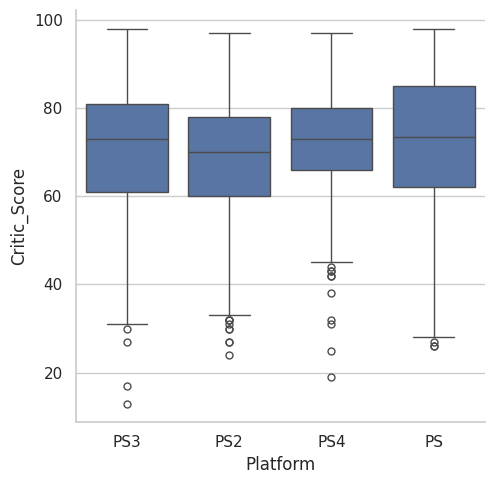

In [35]:
pl = vg[['Global_Sales','Platform','Critic_Score','Rating']][vg.Platform.isin(['PS','PS2','PS3','PS4'])]

sns.catplot(x="Platform", y="Critic_Score", kind="box", data=pl)


Uma alternativa ao boxplot é o _violinplot_ , onde o formato indica a densidade naquele nível:

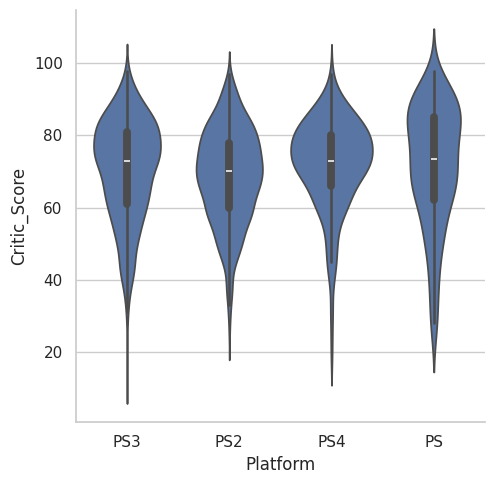

In [36]:
sns.catplot(x="Platform", y="Critic_Score", kind="violin", data=pl)

## Visualizando múltiplas variáveis

Até agora, focamos em apenas duas variáveis. Uma forma simples de analisar 3 variáveis (2 numéricas e 1 categórica) é o uso de váriaveis condicionantes na hora de plotar.

No plot abaixo, usamos a Plataforma como condicionante (no caso temos 4 variáveis, pois o rating também está representado:

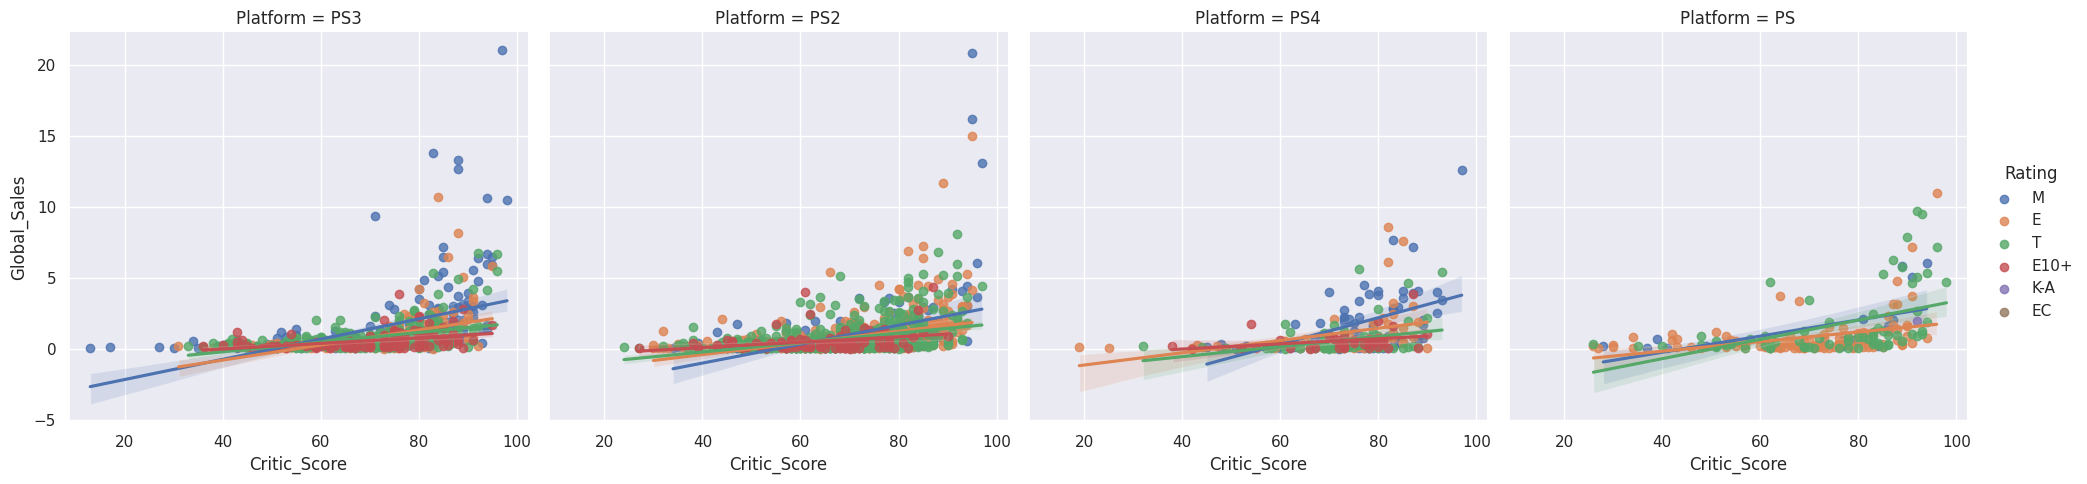

In [37]:
sns.set(style="darkgrid")
sns.lmplot(y="Global_Sales",x="Critic_Score",col="Platform",hue='Rating',data=pl,height=5)